# Comparison: Numerov - Whittaker
This notebook compares the Numerov method (with and without model potentials) to the Whittaker method for calculating Rydberg wavefunctions and matrix elements.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import rydstate

## Wavefunction

In [2]:
states: dict[str, rydstate.RydbergStateSQDT] = {}

In [3]:
state = rydstate.RydbergStateSQDTAlkali("Rb", n=21, l=0, j=0.5, potential="marinescu_1994")
state = rydstate.RydbergStateSQDTAlkali("Rb", n=9, l=1, j=1.5)

state.radial.integrate_wavefunction("numerov")
states["Numerov with Model Potentials"] = state

# Using Numerov without model potentials will lead to some warnings,
# since the resulting wavefunction does not pass all heuristic checks
state_without_mp = rydstate.RydbergStateSQDTAlkali.from_angular_ket(
    state.species, state.angular, state.n, potential="coulomb"
)
state_without_mp.radial.integrate_wavefunction("numerov")
states["Numerov without Model Potentials"] = state_without_mp

The wavefunction for the radial_ket RadialKet(nu=6.350837333725099, potential=PotentialCoulombRubidium(l_r=1)) has some issues:
      The wavefunction is not close to zero at the inner boundary (inner_weight_scaled_to_whole_grid=4.07e-02)
      The wavefunction has 5 nodes, but should have 7 nodes.


In [4]:
state_whittaker = rydstate.RydbergStateSQDTAlkali.from_angular_ket(state.species, state.angular, state.n)
state_whittaker.radial.integrate_wavefunction("whittaker")
states["Whittaker"] = state_whittaker

Using Whittaker to get the wavefunction is not recommended! Use this only for comparison.


RydbergStateSQDTAlkali(Rb, n=9, nu=6.350837333725099, LS(i_c=0.0, s_c=0.0, l_c=0, s_r=0.5, l_r=1, s_tot=0.5, l_tot=1, j_tot=1.5, f_tot=1.5))


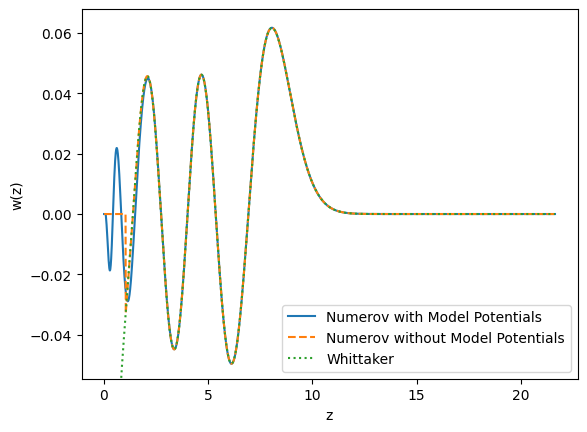

In [5]:
fig, ax = plt.subplots()
print(state)

styles = ["-", "--", ":"]
for i, (label, _state) in enumerate(states.items()):
    ax.plot(_state.radial.z_list, _state.radial.w_list, ls=styles[i], label=label)
ax.legend()

ax.set_xlabel("z")
ax.set_ylabel("w(z)")

ax.set_ylim(1.1 * np.min(state.radial.w_list), 1.1 * np.max(state.radial.w_list))

plt.show()

## Radial matrix elements

In [6]:
state1 = rydstate.RydbergStateSQDTAlkali("Rb", n=10, l=0, j=0.5)
state1.radial.integrate_wavefunction("numerov")
state2 = rydstate.RydbergStateSQDTAlkali("Rb", n=9, l=1, j=1.5)
state2.radial.integrate_wavefunction("numerov")
dipole_me = state1.radial.calc_matrix_element(state2.radial, 1)
print(f"Numerov with model potentials: {dipole_me}", flush=True)

state1 = rydstate.RydbergStateSQDTAlkali("Rb", n=10, l=0, j=0.5, potential="coulomb")
state1.radial.integrate_wavefunction("numerov")
state2 = rydstate.RydbergStateSQDTAlkali("Rb", n=9, l=1, j=1.5, potential="coulomb")
state2.radial.integrate_wavefunction("numerov")
dipole_me = state1.radial.calc_matrix_element(state2.radial, 1)
print(f"Numerov without model potentials: {dipole_me}", flush=True)

state1 = rydstate.RydbergStateSQDTAlkali("Rb", n=10, l=0, j=0.5)
state1.radial.integrate_wavefunction("whittaker")
state2 = rydstate.RydbergStateSQDTAlkali("Rb", n=9, l=1, j=1.5)
state2.radial.integrate_wavefunction("whittaker")
dipole_me = state1.radial.calc_matrix_element(state2.radial, 1)
print(f"Whittaker: {dipole_me}", flush=True)

Numerov with model potentials: 43.640427394637776 bohr


The wavefunction for the radial_ket RadialKet(nu=6.864783105371448, potential=PotentialCoulombRubidium(l_r=0)) has some issues:
      The wavefunction has 6 nodes, but should have 9 nodes.
      The integration for l=0 did stop at 0.14 (should be close to zero).
The wavefunction for the radial_ket RadialKet(nu=6.350837333725099, potential=PotentialCoulombRubidium(l_r=1)) has some issues:
      The wavefunction is not close to zero at the inner boundary (inner_weight_scaled_to_whole_grid=4.07e-02)
      The wavefunction has 5 nodes, but should have 7 nodes.


Numerov without model potentials: 43.60588874251322 bohr


Using Whittaker to get the wavefunction is not recommended! Use this only for comparison.
Using Whittaker to get the wavefunction is not recommended! Use this only for comparison.


Whittaker: 43.561313364176684 bohr
